# 单通道语音增强 · 从谱减法到理想掩蔽

按顺序运行每个单元格。每一块都对应一个方法，最后有统一的对比。

| 块 | 内容 |
|---|---|
| 0 | 工具函数（试听、保存） |
| 1 | 合成语音信号 |
| 2 | 加噪声（噪声会随时间变大） |
| 3 | STFT 分析 |
| 4 | 方法A：谱减法（1979） |
| 5 | 方法B：维纳 + 判决引导（1984） |
| 6 | 方法C：最小值统计噪声估计（2001） |
| 7 | 上限：IRM 理想掩蔽（oracle） |
| 8 | 对比：数字 / 试听 / 图 |

## 块 0 · 工具函数

只需运行一次。

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, istft
from scipy.io import wavfile
from IPython.display import Audio, display

def save(name, sig, sr=16000):
    sig = np.clip(sig, -1, 0.99997)          # 削波保护
    wavfile.write(name, sr, (sig * 32768).astype(np.int16))

def listen(sig, name=None, sr=16000):
    if name:
        save(name, sig, sr)
    display(Audio(np.clip(sig, -1, 0.99997), rate=sr))

def spec(sig, sr=16000):
    """返回 (频率轴, 时间轴, 复数频谱)"""
    return stft(sig, sr, nperseg=400, noverlap=240)

def rec(G, Xn, sr=16000, length=None):
    """频谱乘增益后还原成波形"""
    y = istft(Xn * G, sr, nperseg=400, noverlap=240)[1]
    return y[:length] if length else y

def show_spec(sig, title="", sr=16000, vmin=-100, vmax=-20):
    f, tt, S = spec(sig, sr)
    plt.figure(figsize=(9, 3))
    plt.pcolormesh(tt, f, 20*np.log10(np.abs(S)+1e-8),
                   shading="auto", vmin=vmin, vmax=vmax)
    plt.ylabel("Frequency (Hz)"); plt.xlabel("Time (s)")
    plt.title(title); plt.colorbar(label="dB"); plt.show()

print("工具函数已就绪")

工具函数已就绪


## 块 1 · 合成语音

用**源-滤波器模型**的简化版造一段"类语音"：

- 14 个谐波叠加（基频 150 Hz，幅度按 1/k 衰减 → −6 dB/倍频程，模拟真人声带）
- 乘 `sin²` 包络制造音节起伏（2 秒 8 个"音节"）
- 前 0.3 秒静音（后面噪声估计要用）

x.shape = (96000,)


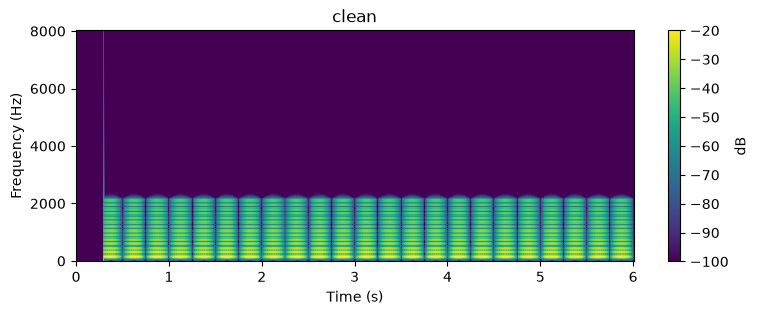

In [2]:
sr  = 16000
dur = 6.0
t   = np.arange(0, dur, 1/sr)

x = np.zeros(len(t))
for k in range(1, 15):
    x = x + np.sin(2*np.pi*150*k*t) / k      # 第k个谐波，幅度 1/k

x = x * np.sin(2*np.pi*2*t)**2               # 音节包络
x[t < 0.3] = 0                               # 开头静音
x = x / np.max(np.abs(x)) * 0.5              # 归一化，防削波

print("x.shape =", x.shape)
listen(x, "clean.wav")
show_spec(x, "clean")

## 块 2 · 加噪声

噪声音量在第 3 秒后**上升约 10 dB**（模拟空调启动）。
用 sigmoid 平滑上升而不是阶跃——阶跃是跳变，会产生全频段的"啪"声。

输入 SNR = 2.35 dB


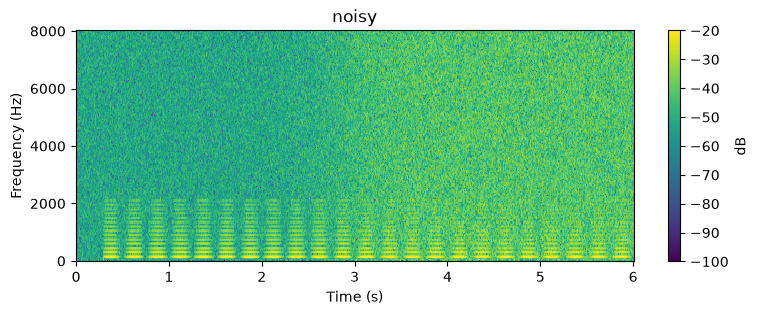

In [3]:
rng   = np.random.default_rng(0)                          # 固定随机种子，结果可复现
level = 0.05 * (1 + 2.2/(1 + np.exp(-(t - 3.0)*4)))       # 0.05 -> 0.16
noise = level * rng.standard_normal(len(t))
noisy = x + noise

def snr_of(est, ref=None):
    ref = x if ref is None else ref
    est = est[:len(ref)]
    return 10*np.log10(np.mean(ref**2) / np.mean((est - ref)**2))

print(f"输入 SNR = {snr_of(noisy):.2f} dB")
listen(noisy, "noisy.wav")
show_spec(noisy, "noisy")

## 块 3 · STFT 分析

| 参数 | 值 | 含义 |
|---|---|---|
| nperseg | 400 | 帧长 25 ms |
| noverlap | 240 | 重叠，帧移 = 400−240 = 160 点 = 10 ms |
| 频点数 | 201 | = 400/2 + 1，频率分辨率 40 Hz |

In [ ]:
f, tt, Xn = spec(noisy)
power = np.abs(Xn)**2                 # 每个时频点的功率

# 真实的干净语音/噪声频谱 —— 只有做实验才拿得到，用于算上限
C  = spec(x)[2]             #clean
N  = spec(noise)[2]         #noise
Nt = np.abs(N)**2

print("power.shape =", power.shape, " (201 频点 x", power.shape[1], "帧)")
print("频率分辨率 =", sr/400, "Hz   帧率 =", sr/160, "fps")

power.shape = (201, 601)  (201 频点 x 601 帧)
频率分辨率 = 40.0 Hz   帧率 = 100.0 fps


## 块 4 · 方法 A：谱减法（Boll, 1979）

$$G = \max\left(1 - \frac{P_{noise}}{P_{obs}},\ \beta\right)$$

噪声估计用最原始的方式：**假设前 25 帧（0.25 秒）是纯噪声**，取平均后永久固定。

听的时候注意那种**忽隐忽现的"水滴声"**——这就是音乐噪声。

In [5]:
noise_fixed = np.mean(power[:, :25], axis=1, keepdims=True)   # (201, 1)

G_ss = np.maximum(1 - noise_fixed/(power + 1e-10), 0.1)       # 谱底 0.1
y_ss = rec(G_ss, Xn, length=len(x))

print(f"谱减法 SNR = {snr_of(y_ss):.2f} dB")
listen(y_ss, "A_specsub.wav")

谱减法 SNR = 3.40 dB


## 块 5 · 方法 B：维纳 + 判决引导（Ephraim & Malah, 1984）

两个改动：

1. **增益换成维纳形式** $G = \dfrac{\xi}{1+\xi}$，其中 $\xi$ 是**先验信噪比**（语音功率/噪声功率）
2. **判决引导估计 $\xi$**：$\xi_t = \alpha\, G_{t-1}^2\gamma_{t-1} + (1-\alpha)\max(\gamma_t - 1, 0)$

$G_{t-1}^2\gamma_{t-1}$ 是"上一帧输出功率 ÷ 噪声功率"。$\alpha=0.98$ 意味着 98% 信历史、2% 信当前帧——**这个时间平滑就是音乐噪声消失的原因**。

注意这里第一次出现**有状态的循环**：每帧的结果依赖上一帧。这正是实时算法的基本形态。

In [6]:
def wiener_dd(power, Xn, noise_mat, alpha=0.98):
    """noise_mat 形状 (201, 帧数)。返回 (波形, 增益矩阵)"""
    G = np.zeros_like(power)
    G_prev = gamma_prev = None                      # 状态变量

    for i in range(power.shape[1]):                 # 逐帧
        gamma = power[:, i] / np.maximum(noise_mat[:, i], 1e-12)   # 后验信噪比

        if G_prev is None:
            xi = np.maximum(gamma - 1, 0)           # 第一帧没有历史
        else:
            xi = alpha * G_prev**2 * gamma_prev + (1-alpha) * np.maximum(gamma - 1, 0)

        xi = np.maximum(xi, 1e-6)
        g  = xi / (1 + xi)                          # 维纳增益

        G[:, i] = g
        G_prev, gamma_prev = g, gamma               # 存给下一帧

    return rec(G, Xn, length=len(x)), G


# 噪声估计仍用固定的那一套，只换增益 —— 这样才看得出增益改进的贡献
noise_fixed_mat = np.repeat(noise_fixed, power.shape[1], axis=1)
y_w, G_w = wiener_dd(power, Xn, noise_fixed_mat)

print(f"维纳+判决引导 SNR = {snr_of(y_w):.2f} dB")
listen(y_w, "B_wiener.wav")

维纳+判决引导 SNR = 5.31 dB


## 块 6 · 方法 C：最小值统计噪声估计（Martin, 2001）

上面两种都假设"噪声永远不变"。第 3 秒后噪声涨了 10 dB，它们完全跟不上。

Martin 的观察：**即使有人一直在说话，每个频点的能量在一段时间内总会掉到接近噪声底。**
所以在滑动窗内取最小值就能追踪噪声，**不需要"开头是静音"这个假设**。

三个参数都是权衡：

| 参数 | 调大 | 调小 |
|---|---|---|
| `win` 窗长 | 更稳，跟踪更慢 | 跟踪快，易把语音当噪声 |
| `alpha_s` 平滑 | 抖动小，反应慢 | 反应快，估计噪 |
| `bias` 补偿 | 抑制更狠，语音失真↑ | 抑制不足，噪声残留↑ |

⚠️ `alpha_s` 不能太大。平滑过头会让最小值降不到真实噪声底，
导致噪声被高估、语音被误压（0.9 时 SNR 只有 1.6 dB，0.7 时有 8.2 dB）。

In [17]:
def estimate_noise_minstat(power, win=60, alpha_s=0.7, bias=1.0):
    n_freq, n_frames = power.shape
    noise_est = np.zeros_like(power)
    S   = power[:, 0].copy()      # 平滑后的功率谱。切片要 .copy()
    buf = []                      # 滑动窗历史

    for i in range(n_frames):
        S = alpha_s * S + (1 - alpha_s) * power[:, i]        # ① 时间平滑
        buf.append(S.copy())
        if len(buf) > win:
            buf.pop(0)                                       # ② 只留最近 win 帧
        noise_est[:, i] = bias * np.min(np.stack(buf), axis=0)   # ③ 取最小 x 补偿

    return noise_est


noise_est = estimate_noise_minstat(power)
y_ms, G_ms = wiener_dd(power, Xn, noise_est)

print(f"维纳+判决引导+最小值统计 SNR = {snr_of(y_ms):.2f} dB")
listen(y_ms, "C_minstat.wav")

维纳+判决引导+最小值统计 SNR = 8.24 dB


### 噪声估计跟踪效果

红色虚线（固定估计）追不上噪声上升；橙色（最小值统计）跟上了，但**慢半拍**。
那个滞后就是这类方法的固有代价。

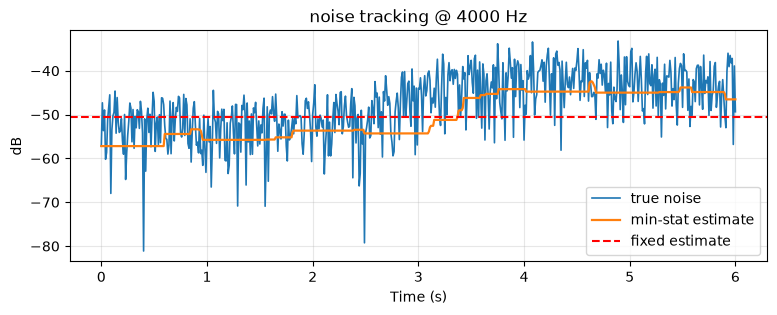

In [18]:
k = 100                                       # 第100个频点 = 100 x 40 = 4000 Hz

plt.figure(figsize=(9, 3))
plt.plot(tt, 10*np.log10(Nt[k] + 1e-12),        lw=1.2, label="true noise")
plt.plot(tt, 10*np.log10(noise_est[k] + 1e-12), lw=1.6, label="min-stat estimate")
plt.axhline(10*np.log10(noise_fixed[k, 0]), ls="--", c="r", label="fixed estimate")
plt.xlabel("Time (s)"); plt.ylabel("dB"); plt.title("noise tracking @ 4000 Hz")
plt.legend(); plt.grid(alpha=.3); plt.show()

## 块 7 · 上限：IRM 理想掩蔽（oracle）

$$\mathrm{IRM} = \sqrt{\frac{|S|^2}{|S|^2+|N|^2}}$$

**注意它的形状——这就是维纳增益**，只不过 $\xi$ 用的是真值而非估计值。

现实中算不出来（需要知道干净语音，而那正是要求的东西）。
这叫 **oracle 实验**：故意作弊，用来测出"如果掩蔽估计得完美，能好到什么程度"。

**深度学习要做的，就是让网络去逼近这个 IRM。**

In [20]:
S2, N2 = np.abs(C)**2, np.abs(N)**2

IRM = np.sqrt(S2 / (S2 + N2 + 1e-12))         # 理想比值掩蔽
IBM = (S2 > N2).astype(float)                 # 理想二值掩蔽（非0即1）

y_irm = rec(IRM, Xn, length=len(x))
y_ibm = rec(IBM, Xn, length=len(x))

print(f"IRM (理想比值掩蔽) SNR = {snr_of(y_irm):.2f} dB")
print(f"IBM (理想二值掩蔽) SNR = {snr_of(y_ibm):.2f} dB")
print(f"\n我们估的增益 与 IRM 的平均差距 = {np.mean(np.abs(G_ms - IRM)):.3f}")
listen(y_irm, "D_irm_oracle.wav")

IRM (理想比值掩蔽) SNR = 13.98 dB
IBM (理想二值掩蔽) SNR = 14.43 dB

我们估的增益 与 IRM 的平均差距 = 0.210


## 块 8 · 统一对比

In [10]:
results = [
    ("不处理",                     noisy),
    ("A 谱减法",                   y_ss),
    ("B 维纳+判决引导",             y_w),
    ("C +最小值统计",               y_ms),
    ("D IRM 理想掩蔽 (上限)",       y_irm),
]

print(f"{'方法':24s}{'SNR (dB)':>10s}")
print("-"*34)
for name, y_ in results:
    print(f"{name:24s}{snr_of(y_):10.2f}")

方法                        SNR (dB)
----------------------------------
不处理                           2.35
A 谱减法                         3.40
B 维纳+判决引导                     5.31
C +最小值统计                      8.24
D IRM 理想掩蔽 (上限)              13.98


### 试听（按顺序）

In [22]:
for name, y_ in results:
    print(name)
    listen(y_)

不处理


A 谱减法


B 维纳+判决引导


C +最小值统计


D IRM 理想掩蔽 (上限)


### 增益矩阵对比

- **谱减法**：静音区布满**孤立亮点** = 音乐噪声
- **维纳+DD**：明显平滑
- **IRM**：紧紧贴合谐波，边界清晰 —— 这就是差距所在

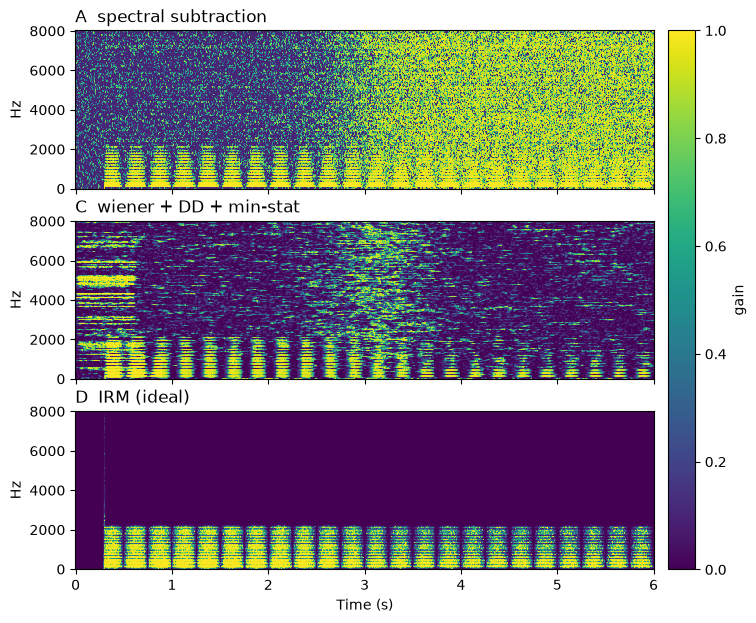

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, G_, name in zip(axes, [G_ss, G_ms, IRM],
                        ["A  spectral subtraction", "C  wiener + DD + min-stat", "D  IRM (ideal)"]):
    im = ax.pcolormesh(tt, f, G_, shading="auto", vmin=0, vmax=1)
    ax.set_title(name, loc="left"); ax.set_ylabel("Hz")
axes[-1].set_xlabel("Time (s)")
fig.colorbar(im, ax=axes, label="gain", pad=0.02)
plt.show()

### 语谱图对比

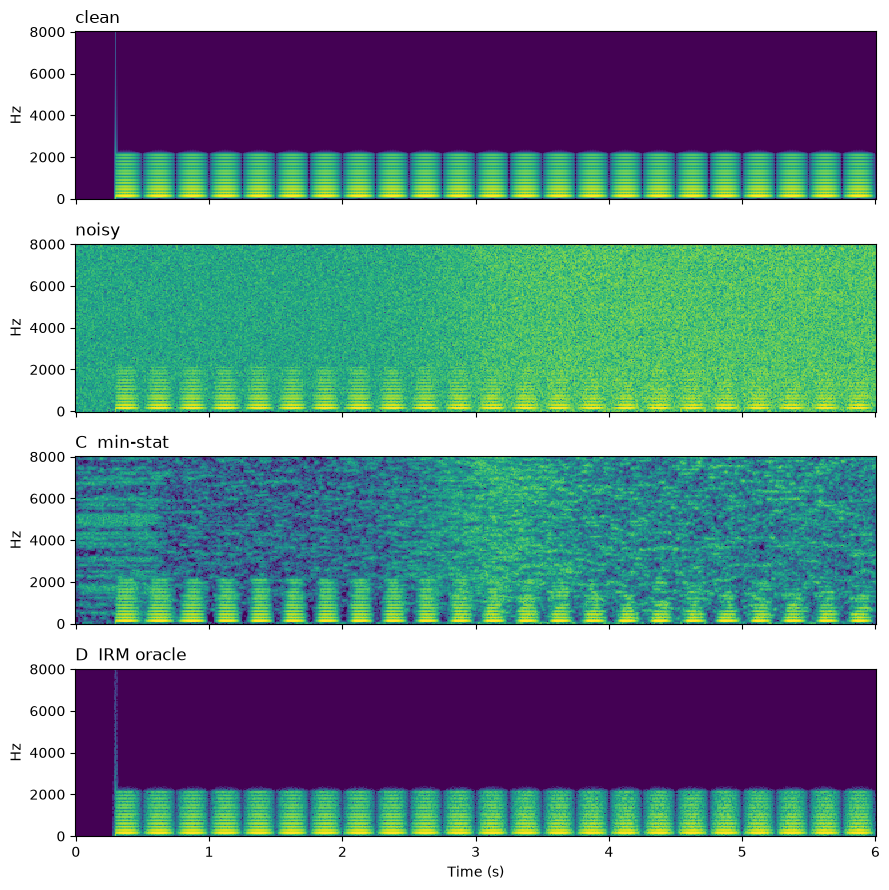

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True)
for ax, sig, name in zip(axes, [x, noisy, y_ms, y_irm],
                         ["clean", "noisy", "C  min-stat", "D  IRM oracle"]):
    ff, ttt, S = spec(sig)
    ax.pcolormesh(ttt, ff, 20*np.log10(np.abs(S)+1e-8),
                  shading="auto", vmin=-100, vmax=-20)
    ax.set_title(name, loc="left"); ax.set_ylabel("Hz")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()

---

## 小结

| 方法 | 解决了什么 | 还剩什么问题 |
|---|---|---|
| 谱减法 | 能降噪 | 音乐噪声严重 |
| + 判决引导 | 音乐噪声基本消失 | 噪声一变化就失效 |
| + 最小值统计 | 噪声变化能跟上 | 跟踪滞后约 1 秒；离 IRM 还差很远 |
| IRM (oracle) | —— | 现实中拿不到 |

**下一步：用神经网络从数据里学出这个掩蔽。**